# Praktikum Hari 2 — Bagian 1: Evaluasi dan Perbandingan Model
## AquaSmart AIoT (mengikuti `MODUL_PRAKTIKUM2.pdf` langkah 1.0–1.9)

| | |
|---|---|
| **Nama / NIM** | Alpin Aditya Pratama (V3925004), Dimas Aryo Sejati (V3925022) |
| **Kelas / Project** | D3 Teknik Informatika K Kab. Madiun — AquaSmart AIoT |

Notebook ini menjalankan **setiap langkah 1.0–1.9 Bagian 1** modul memakai
**data sensor AquaSmart yang sebenarnya** (hasil pembersihan Hari 1), bukan
dataset contoh triase klinik yang ada di modul. Jawaban tertulis Soal 1–3
(Tugas Mandiri) ada di berkas terpisah `JAWABAN_TUGAS_MANDIRI_HARI_2.md` /
`Tugas_Mandiri_Hari_2_AquaSmart.docx` pada folder yang sama; notebook ini
adalah bukti bahwa seluruh langkah praktikum juga benar-benar dijalankan,
bukan hanya dirangkum.

**Sumber data:** `../tugas_mandiri/fitur_dan_target.csv` dan
`../tugas_mandiri/data_bersih_5menit.csv` — keluaran pembersihan Hari 1 yang
sudah di-commit ke Git (CSV mentah 505.730 baris sengaja tidak ikut commit,
lihat `README_MANDIRI.md`). Aturan ambang dibaca ulang dari
`ThresholdRules.php` lewat modul `mandiri.py` Hari 1, bukan ditulis ulang.

## 1.0 Menyiapkan Kembali Hasil Hari 1

CSV mentah tidak ikut di-commit, jadi langkah ini tidak mengulang pembersihan
dari awal. Sebagai gantinya, fitur dan label bersih hasil Hari 1 (sudah
di-commit) dimuat kembali, lalu baseline Random Forest Hari 1 dilatih ulang
dengan konfigurasi dan `random_state` yang sama supaya hasilnya identik.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SISTEM_CERDAS = Path('..').resolve()
sys.path.insert(0, str(SISTEM_CERDAS))
import mandiri  # Hari 1: RULES, pipeline(), chronological_split(), score()

FITUR = SISTEM_CERDAS / 'tugas_mandiri/fitur_dan_target.csv'
BINS = SISTEM_CERDAS / 'tugas_mandiri/data_bersih_5menit.csv'
print('Fitur Hari 1 tersedia:', FITUR.exists())
print('Bin 5 menit Hari 1 tersedia:', BINS.exists())
print('Aturan ambang (ThresholdRules.php):', mandiri.RULES)

Fitur Hari 1 tersedia: True
Bin 5 menit Hari 1 tersedia: True
Aturan ambang (ThresholdRules.php): {'PH_MIN': 6.5, 'PH_MAX': 8.5, 'TEMP_MIN': 25.0, 'TEMP_MAX': 30.0}


## 1.1 Memuat Hasil Hari 1

Split data memakai `chronological_split()` yang sama persis dengan Hari 1:
urut waktu, purge 60 menit di batas holdout, `random_state=42`. Fungsi
`buat_pipe()` membuat satu alur yang sama untuk setiap model: preprocessing
Hari 1 (imputer median + scaler) lalu model.

In [2]:
df = pd.read_csv(FITUR, parse_dates=['timestamp']).set_index('timestamp').sort_index()
y = df.pop('target_proxy').astype(int)
X = df

X_train, X_test, y_train, y_test = mandiri.chronological_split(X, y)


def buat_pipe(model):
    return mandiri.pipeline(X.columns, estimator=model)


print('Data latih:', X_train.shape, '| Data uji:', X_test.shape)
print('Proporsi kelas "di luar ambang" (1) di data latih:', round(y_train.mean(), 3))

Data latih: (8525, 12) | Data uji: (2135, 12)
Proporsi kelas "di luar ambang" (1) di data latih: 0.91


## 1.2 Confusion Matrix Model Hari 1

Model Hari 1: Random Forest (`n_estimators=160, max_depth=10,
min_samples_leaf=5, class_weight='balanced', random_state=42`).

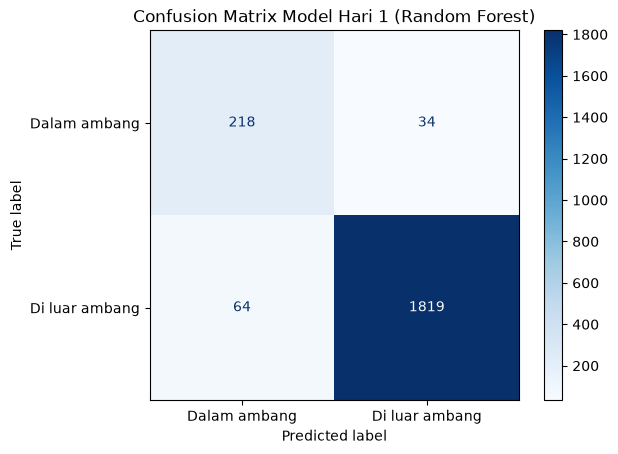

                precision    recall  f1-score   support

  Dalam ambang       0.77      0.87      0.82       252
Di luar ambang       0.98      0.97      0.97      1883

      accuracy                           0.95      2135
     macro avg       0.88      0.92      0.90      2135
  weighted avg       0.96      0.95      0.96      2135



In [3]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

model_hari1 = mandiri.pipeline(X.columns)
model_hari1.fit(X_train, y_train)
y_pred = model_hari1.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Dalam ambang', 'Di luar ambang'], cmap='Blues')
plt.title('Confusion Matrix Model Hari 1 (Random Forest)')
plt.show()

print(classification_report(y_test, y_pred,
                             target_names=['Dalam ambang', 'Di luar ambang'], zero_division=0))

## 1.3 Mencoba Beberapa Threshold

Mengikuti kode modul apa adanya: Random Forest polos (`n_estimators=200`,
tanpa `class_weight`), peluang dihitung dengan 5-fold cross-validation di
data latih, lalu precision/recall/F1 dilihat pada beberapa threshold. Data
uji tetap disegel.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score

rf = buat_pipe(RandomForestClassifier(n_estimators=200, random_state=42))

peluang = cross_val_predict(rf, X_train, y_train, cv=5, method='predict_proba')[:, 1]

for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    pred = (peluang >= t).astype(int)
    print(f'threshold={t:.1f}  '
          f'Precision={precision_score(y_train, pred, zero_division=0):.3f}  '
          f'Recall={recall_score(y_train, pred, zero_division=0):.3f}  '
          f'F1={f1_score(y_train, pred, zero_division=0):.3f}')

threshold=0.2  Precision=0.937  Recall=0.962  F1=0.949
threshold=0.3  Precision=0.944  Recall=0.943  F1=0.943
threshold=0.4  Precision=0.949  Recall=0.938  F1=0.944
threshold=0.5  Precision=0.948  Recall=0.835  F1=0.888
threshold=0.6  Precision=0.948  Recall=0.803  F1=0.869


**Catatan adaptasi.** Precision/recall/F1 di atas dihitung terhadap kelas
1 ("di luar ambang"), persis kode modul. Karena kelas itu **mayoritas** di
AquaSmart (~91%, kebalikan dari triase di modul yang minoritas), F1 kelas 1
saja gampang tinggi walau model tidak benar-benar pintar. Karena itu langkah
1.4 dan seterusnya di bawah memakai **macro F1** (rata-rata kedua kelas)
sebagai metrik pembanding utama, sama seperti yang dipakai Hari 1 dan Soal 1
Tugas Mandiri — bukan `scoring='f1'` biasa seperti contoh modul.

## 1.4 Membandingkan Dua Model

Logistic Regression vs Random Forest, keduanya `class_weight='balanced'`,
5-fold cross-validation.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer

MACRO_F1 = make_scorer(f1_score, average='macro', zero_division=0)

kandidat = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                             random_state=42),
}


def ringkas(nilai):
    return f'{nilai.mean():.3f} ± {nilai.std():.3f}'


hasil = []
for nama, model in kandidat.items():
    cv = cross_validate(buat_pipe(model), X_train, y_train, cv=5,
                         scoring={'precision': 'precision', 'recall': 'recall',
                                  'f1_macro': MACRO_F1})
    hasil.append({'Model': nama,
                  'Precision': ringkas(cv['test_precision']),
                  'Recall': ringkas(cv['test_recall']),
                  'Macro F1': ringkas(cv['test_f1_macro'])})

print(pd.DataFrame(hasil).to_string(index=False))

              Model     Precision        Recall      Macro F1
Logistic Regression 0.992 ± 0.011 0.825 ± 0.180 0.739 ± 0.155
      Random Forest 0.959 ± 0.032 0.940 ± 0.065 0.713 ± 0.143


## 1.5 Hyperparameter Tuning dengan GridSearchCV

Mencoba kombinasi `n_estimators` × `max_depth` pada Random Forest, dipilih
dengan macro F1 (bukan `scoring='f1'` polos — lihat catatan langkah 1.3).

In [6]:
from sklearn.model_selection import GridSearchCV

parameter = {'model__n_estimators': [100, 160, 300],
             'model__max_depth': [6, 10, None]}

grid = GridSearchCV(
    buat_pipe(RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=2)),
    parameter, cv=5, scoring=MACRO_F1)
grid.fit(X_train, y_train)

print('Parameter terbaik :', grid.best_params_)
print(f'Macro F1 terbaik (CV) : {grid.best_score_:.3f}')

tabel = pd.DataFrame(grid.cv_results_)[['params', 'mean_test_score']]
print(tabel.sort_values('mean_test_score', ascending=False).round(3).to_string(index=False))

Parameter terbaik : {'model__max_depth': 6, 'model__n_estimators': 100}
Macro F1 terbaik (CV) : 0.798
                                                params  mean_test_score
   {'model__max_depth': 6, 'model__n_estimators': 100}            0.798
   {'model__max_depth': 6, 'model__n_estimators': 160}            0.796
   {'model__max_depth': 6, 'model__n_estimators': 300}            0.796
  {'model__max_depth': 10, 'model__n_estimators': 300}            0.735
  {'model__max_depth': 10, 'model__n_estimators': 160}            0.731
  {'model__max_depth': 10, 'model__n_estimators': 100}            0.729
{'model__max_depth': None, 'model__n_estimators': 100}            0.713
{'model__max_depth': None, 'model__n_estimators': 160}            0.712
{'model__max_depth': None, 'model__n_estimators': 300}            0.712


## 1.6 Mengenali Overfitting dan Underfitting

Decision Tree di berbagai `max_depth`, macro F1 data latih vs validasi
(5-fold CV, `return_train_score=True`).

max_depth=1     Macro F1 latih=0.618  Macro F1 validasi=0.572


max_depth=2     Macro F1 latih=0.881  Macro F1 validasi=0.770


max_depth=3     Macro F1 latih=0.908  Macro F1 validasi=0.797
max_depth=5     Macro F1 latih=0.945  Macro F1 validasi=0.769


max_depth=8     Macro F1 latih=0.965  Macro F1 validasi=0.740
max_depth=12    Macro F1 latih=0.991  Macro F1 validasi=0.735


max_depth=None  Macro F1 latih=1.000  Macro F1 validasi=0.736


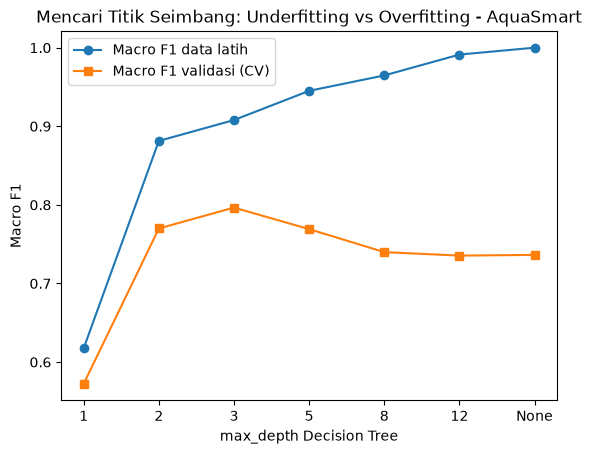

In [7]:
from sklearn.tree import DecisionTreeClassifier

kedalaman = [1, 2, 3, 5, 8, 12, None]
f1_latih, f1_validasi = [], []

for d in kedalaman:
    cv = cross_validate(buat_pipe(DecisionTreeClassifier(max_depth=d, random_state=42)),
                         X_train, y_train, cv=5, scoring=MACRO_F1, return_train_score=True)
    f1_latih.append(cv['train_score'].mean())
    f1_validasi.append(cv['test_score'].mean())
    print(f'max_depth={str(d):<5} Macro F1 latih={f1_latih[-1]:.3f}  '
          f'Macro F1 validasi={f1_validasi[-1]:.3f}')

label = [str(d) for d in kedalaman]
plt.plot(label, f1_latih, 'o-', label='Macro F1 data latih')
plt.plot(label, f1_validasi, 's-', label='Macro F1 validasi (CV)')
plt.xlabel('max_depth Decision Tree')
plt.ylabel('Macro F1')
plt.title('Mencari Titik Seimbang: Underfitting vs Overfitting - AquaSmart')
plt.legend()
plt.show()

## 1.7 Deep Learning Sederhana: Multilayer Perceptron

MLP dengan dua hidden layer (16 dan 8 neuron), `early_stopping=True`,
dibandingkan dengan hasil langkah 1.4.

MLP  Recall alarm=0.964  Macro F1=0.794 ± 0.082


Berhenti pada epoch ke- 43


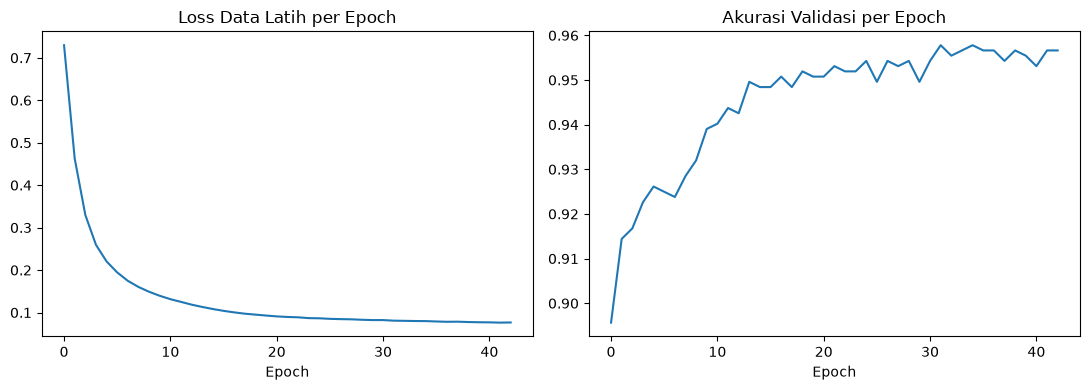

In [8]:
from sklearn.neural_network import MLPClassifier

mlp = buat_pipe(MLPClassifier(hidden_layer_sizes=(16, 8), early_stopping=True,
                               max_iter=500, random_state=42))

cv = cross_validate(mlp, X_train, y_train, cv=5, scoring={'recall': 'recall', 'f1_macro': MACRO_F1})
print(f"MLP  Recall alarm={cv['test_recall'].mean():.3f}  "
      f"Macro F1={cv['test_f1_macro'].mean():.3f} ± {cv['test_f1_macro'].std():.3f}")

mlp.fit(X_train, y_train)
jaringan = mlp.named_steps['model']
print('Berhenti pada epoch ke-', jaringan.n_iter_)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(jaringan.loss_curve_)
ax[0].set_title('Loss Data Latih per Epoch')
ax[0].set_xlabel('Epoch')
ax[1].plot(jaringan.validation_scores_)
ax[1].set_title('Akurasi Validasi per Epoch')
ax[1].set_xlabel('Epoch')
plt.tight_layout()
plt.show()

**Amati:** MLP tidak memakai `class_weight`, sehingga recall alarm bisa
lebih rendah dibanding Random Forest pada langkah 1.4. Pada data tabular
kecil seperti ini, MLP belum tentu lebih baik daripada Random Forest — sesuai
peringatan Dasar Teori modul poin i.

## 1.8 Memilih Model Final dan Uji Sekali

Model terbaik dari GridSearchCV (langkah 1.5) dipakai dengan threshold 0,5
(bawaan) sebagai model final, lalu data uji dibuka **satu kali**.

Model Hari 1                       macro F1=0.8951  Recall alarm=0.966
Model final Hari 2 (GridSearchCV)  macro F1=0.8785  Recall alarm=0.971


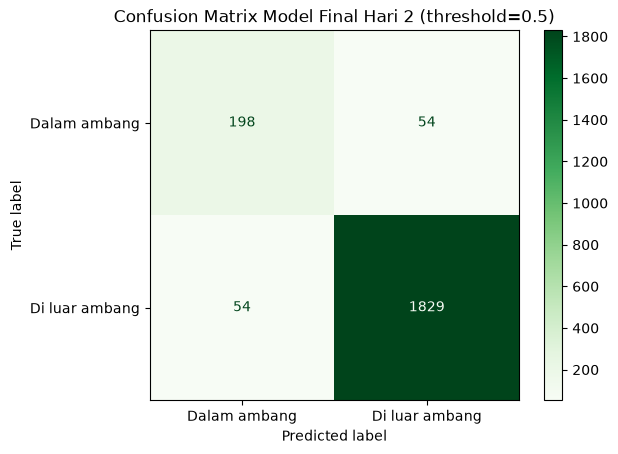

In [9]:
model_final = grid.best_estimator_
THRESHOLD = 0.5

peluang_uji = model_final.predict_proba(X_test)[:, 1]
pred_uji = (peluang_uji >= THRESHOLD).astype(int)

for nama, pred in [('Model Hari 1', model_hari1.predict(X_test)),
                    ('Model final Hari 2 (GridSearchCV)', pred_uji)]:
    print(f'{nama:<34} macro F1={f1_score(y_test, pred, average="macro", zero_division=0):.4f}  '
          f'Recall alarm={recall_score(y_test, pred, zero_division=0):.3f}')

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_uji, display_labels=['Dalam ambang', 'Di luar ambang'], cmap='Greens')
plt.title(f'Confusion Matrix Model Final Hari 2 (threshold={THRESHOLD})')
plt.show()

**Amati:** hasil di sini konsisten dengan Soal 2c/3c pada
`JAWABAN_TUGAS_MANDIRI_HARI_2.md` — model hasil `GridSearchCV` tidak otomatis
mengungguli baseline Hari 1 di data uji, walau skor cross-validation-nya
sama atau lebih tinggi. Kesimpulan itu dibahas lebih lengkap di sana,
termasuk kombinasi threshold rendah (0,3) yang dicoba di Soal 3a.

## 1.9 Pola yang Sama untuk Data Time Series dan Citra (opsional)

Bagian 1 AquaSmart adalah **klasifikasi**, bukan forecasting atau computer
vision, sehingga langkah ini bersifat bonus/opsional, sesuai kalimat modul
"Tim dengan data forecasting atau citra memakai prinsip yang sama". Dua
sub-contoh modul:

- **Forecasting** — dicoba di bawah sebagai bonus, karena data AquaSmart
  memang deret waktu: bandingkan tebakan naif (pakai nilai pH interval
  sebelumnya) dengan Random Forest Regressor untuk memprediksi nilai pH
  kontinu 5 menit ke depan.
- **YOLO (citra)** — **tidak berlaku**. AquaSmart tidak punya dataset citra
  atau model deteksi objek; tidak dipaksakan supaya tidak mengklaim
  kemampuan yang tidak ada.

In [10]:
bins = pd.read_csv(BINS, parse_dates=['timestamp']).set_index('timestamp').sort_index()
y_ph = bins.loc[X.index, 'ph']
y_ph_train, y_ph_test = y_ph.loc[X_train.index], y_ph.loc[X_test.index]

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Model 1: naif musiman - tebak = nilai pH pada interval sebelumnya (ph_lag1)
mae_naive = mean_absolute_error(y_ph_test, X_test['ph_lag1'])

# Model 2: Random Forest Regressor dengan fitur yang sama seperti klasifikasi
rf_ts = RandomForestRegressor(n_estimators=200, random_state=42)
rf_ts.fit(X_train, y_ph_train)
mae_rf = mean_absolute_error(y_ph_test, rf_ts.predict(X_test))

print(f'MAE naif (ph_lag1)      : {mae_naive:.4f} satuan pH')
print(f'MAE Random Forest       : {mae_rf:.4f} satuan pH')

MAE naif (ph_lag1)      : 0.2153 satuan pH
MAE Random Forest       : 0.2983 satuan pH


**Amati:** tebakan naif (pakai nilai pH 5 menit sebelumnya) justru
mengungguli Random Forest Regressor pada bonus ini. Ini konsisten dengan pola
yang sudah dicatat Hari 1 (baseline aturan/persistensi mengungguli Random
Forest untuk klasifikasi) dan Soal 2c/3c di atas (model hasil tuning belum
tentu unggul di data uji): pada data sensor time series jangka pendek
seperti ini, nilai barusan sering menjadi prediktor terkuat, dan model yang
lebih rumit tidak otomatis lebih baik.

## Kesimpulan langkah praktikum

Seluruh langkah 1.0–1.9 Bagian 1 sudah dijalankan memakai data AquaSmart
sendiri. Ringkasan keputusan akhir, tabel perbandingan, dan tiga contoh
kesalahan sistem yang ditemukan selama proses ini didokumentasikan sebagai
jawaban resmi Tugas Mandiri di `JAWABAN_TUGAS_MANDIRI_HARI_2.md` dan
`Tugas_Mandiri_Hari_2_AquaSmart.docx` pada folder yang sama.